# Twitter Sheng vs English — Full NLP Pipeline
**Day 2 Workshop | AI/ML Workshop 2026**

End-to-end pipeline:
1. Sheng-aware text cleaning (custom + data-driven stopwords)
2. Exploratory visualisations
3. Bag of Words features
4. Model 1 — Gradient Boosting (XGBoost)
5. Word Embeddings (Word2Vec + GloVe analogies + t-SNE)
6. Model 2 — SpaCy pretrained vectors
7. Model 3 — Deep Learning (LSTM)
8. Model 4 — H2O AutoML
9. Model comparison

Each model section ends with an **interactive prediction widget**.


## 0. Install Dependencies

In [1]:
# # Run this cell once, then restart the kernel
# !pip install wordcloud gensim spacy h2o ipywidgets xgboost tensorflow openpyxl
# !python -m spacy download en_core_web_md
# print("Dependencies ready — skip if already installed.")


## 1. Imports & Setup

In [1]:
import re, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.util import ngrams as nltk_ngrams
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
import xgboost as xgb

import gensim.downloader as gensim_api
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import spacy

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

import ipywidgets as widgets

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
plt.rcParams['figure.dpi'] = 100
print("All imports OK")


All imports OK


## 2. Load & Explore Data

In [6]:
df = pd.read_excel("cleaned_language_twitter.xlsx")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['language'].value_counts()}")
df.head(5)


Shape: (1000, 2)

Class distribution:
language
positive    500
negative    500
Name: count, dtype: int64


,source,language
0,therapy + journaling + a little sunshine has g...,positive
1,grateful for the friends who check in just to ...,positive
2,the book I ordered arrived and it's even more ...,positive
3,my package arrived a day early. love to see it...,positive
4,went to a local event tonight and met so many ...,positive


## 3. Sheng-Aware Text Cleaning

Sheng is a Kenyan urban creole mixing Swahili, English, and ethnic languages.
Standard English stopwords miss common Sheng filler words.

**Strategy:**
- English NLTK stopwords
- Hand-curated Sheng function/filler words
- Data-driven: top corpus-frequency tokens that carry no discriminative signal


In [7]:
ENGLISH_STOPS = set(stopwords.words('english'))

SHENG_STOPS = {
    'na', 'ni', 'ya', #'wa', 'ka', 'kwa', 'pia', 'sasa', 'hii', 'hiyo',
    # 'ile', 'huyu', 'hawa', 'yake', 'zake', 'wake', 'wao', 'kwake',
    # 'ama', 'au', 'lakini', 'bado', 'tayari', 'sana', 'kidogo', 'kabisa',
    # 'kweli', 'ndiyo', 'hapana', 'ndio', 'aii', 'ai', 'aye', 'eeh',
    # 'aki', 'maze', 'si', 'tu', 'hata', 'juu', 'chini', 'mbele', 'nyuma',
    # 'siku', 'leo', 'jana', 'kesho', 'wakati', 'mara', 'kama', 'kila',

}

ALL_STOPS = ENGLISH_STOPS | SHENG_STOPS
print(f"English stopwords : {len(ENGLISH_STOPS)}")
print(f"Sheng stopwords   : {len(SHENG_STOPS)}")
print(f"Combined total    : {len(ALL_STOPS)}")


English stopwords : 198
Sheng stopwords   : 3
Combined total    : 201


In [8]:
# Data-driven: find high-frequency corpus tokens to add as extra stops
def raw_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

all_raw_tokens = []
for t in df['source']:
    all_raw_tokens.extend(raw_tokenize(t))

corpus_freq = Counter(all_raw_tokens)
candidates = [(w, c) for w, c in corpus_freq.most_common(100)
              if w not in ALL_STOPS and len(w) > 1]

print("Top 30 high-freq corpus words not yet in stoplist:")
print("(Review and add Sheng function words to SHENG_STOPS above)")
for w, c in candidates[:5]:
    print(f"  {w:<20s} {c}")


Top 30 high-freq corpus words not yet in stoplist:
(Review and add Sheng function words to SHENG_STOPS above)
  today                219
  im                   99
  got                  96
  genuinely            94
  day                  84


In [9]:
stemmer = PorterStemmer()

def clean_text(text, use_stemming=True):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in ALL_STOPS and len(t) > 1]
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['cleaned']   = df['source'].apply(lambda x: clean_text(x, use_stemming=True))
df['clean_raw'] = df['source'].apply(lambda x: clean_text(x, use_stemming=False))

print("Sample before/after cleaning:")
for i in range(3):
    print(f"\n[{i}] Original : {df['source'].iloc[i][:110]}")
    print(f"    Cleaned  : {df['cleaned'].iloc[i][:110]}")


Sample before/after cleaning:

[0] Original : therapy + journaling + a little sunshine has genuinely changed my life this year. invest in yourself.
    Cleaned  : therapi journal littl sunshin genuin chang life year invest

[1] Original : grateful for the friends who check in just to say hey. no agenda. just love. you know who you are ðŸ¤
    Cleaned  : grate friend check say hey agenda love know

[2] Original : the book I ordered arrived and it's even more beautiful than the cover photo. starting tonight ðŸ“šâ˜•
    Cleaned  : book order arriv even beauti cover photo start tonight


## 4. Exploratory Text Analysis

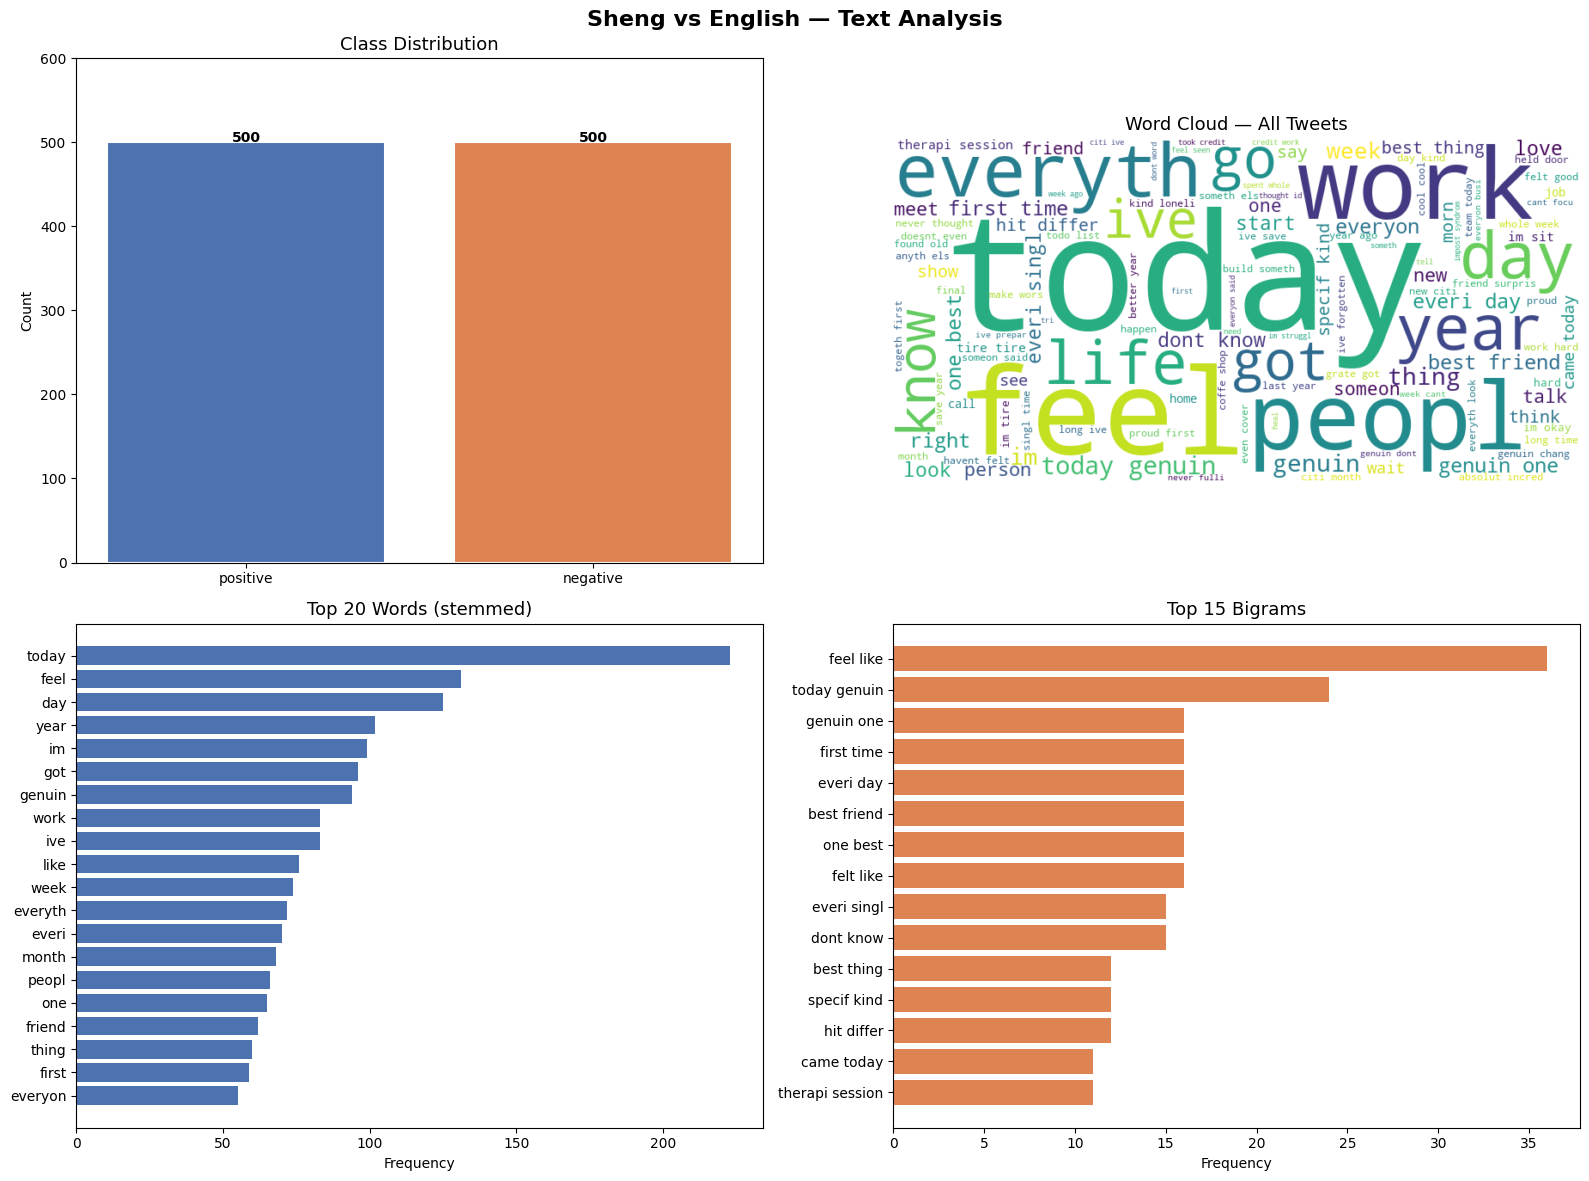

In [10]:
COLORS = ['#4C72B0', '#DD8452']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Sheng vs English — Text Analysis", fontsize=16, fontweight='bold')

# Class distribution
ax = axes[0, 0]
counts = df['language'].value_counts()
bars = ax.bar(counts.index, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
ax.set_title("Class Distribution", fontsize=13)
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.2)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontweight='bold')

# Word cloud
ax = axes[0, 1]
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='viridis', max_words=120).generate(' '.join(df['cleaned']))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title("Word Cloud — All Tweets", fontsize=13)

# Top-20 words
ax = axes[1, 0]
word_freq = Counter(' '.join(df['cleaned']).split()).most_common(20)
words, freqs = zip(*word_freq)
ax.barh(list(words)[::-1], list(freqs)[::-1], color='#4C72B0')
ax.set_title("Top 20 Words (stemmed)", fontsize=13); ax.set_xlabel("Frequency")

# Top-15 bigrams
ax = axes[1, 1]
tokens_all = ' '.join(df['cleaned']).split()
bigrams = Counter([' '.join(b) for b in nltk_ngrams(tokens_all, 2)]).most_common(15)
bw, bf = zip(*bigrams)
ax.barh(list(bw)[::-1], list(bf)[::-1], color='#DD8452')
ax.set_title("Top 15 Bigrams", fontsize=13); ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


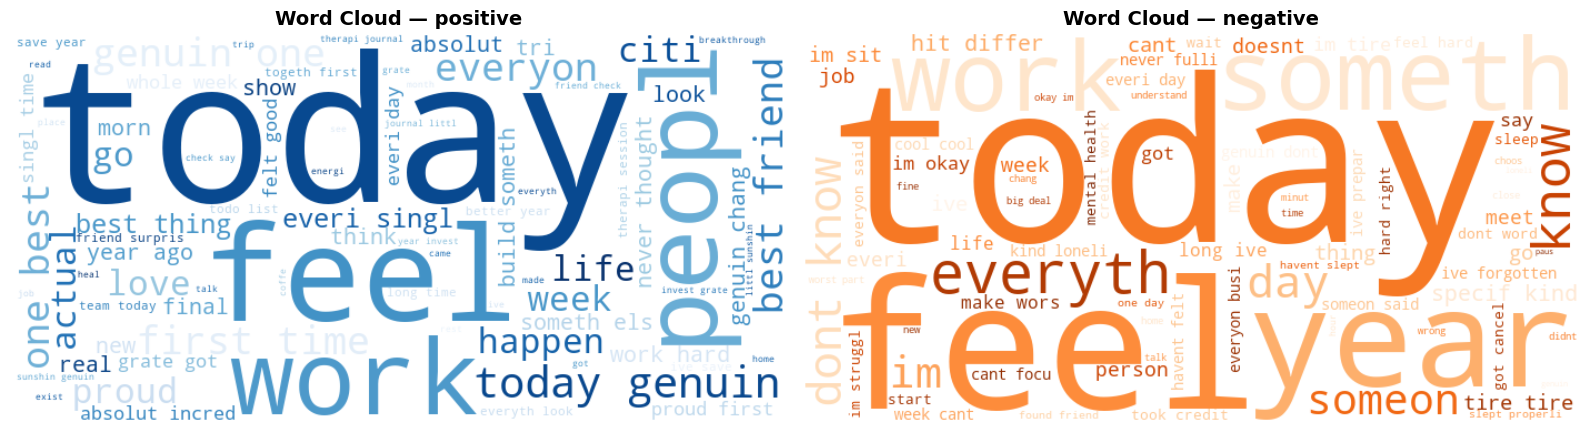

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, lang, cmap in zip(axes, ['positive', 'negative'], ['Blues', 'Oranges']):
    text = ' '.join(df[df['language'] == lang]['cleaned'])
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f"Word Cloud — {lang}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Feature Engineering — Bag of Words

In [12]:
le = LabelEncoder()
y = le.fit_transform(df['language'])
print(f"Labels: {dict(zip(le.classes_, le.transform(le.classes_)))}")

bow_vec = CountVectorizer(max_features=2000, ngram_range=(1, 2))
X_bow = bow_vec.fit_transform(df['cleaned']).toarray()
print(f"BoW matrix shape: {X_bow.shape}")

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train_bow.shape}  |  Test: {X_test_bow.shape}")

print(X_train_bow[:2])
print(y_train[:2])


Labels: {'negative': np.int64(0), 'positive': np.int64(1)}
BoW matrix shape: (1000, 2000)
Train: (800, 2000)  |  Test: (200, 2000)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[1 0]


## 6. Model 1 — Gradient Boosting (XGBoost)

XGBoost Accuracy: 0.9550

              precision    recall  f1-score   support

    negative       0.96      0.95      0.95       100
    positive       0.95      0.96      0.96       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



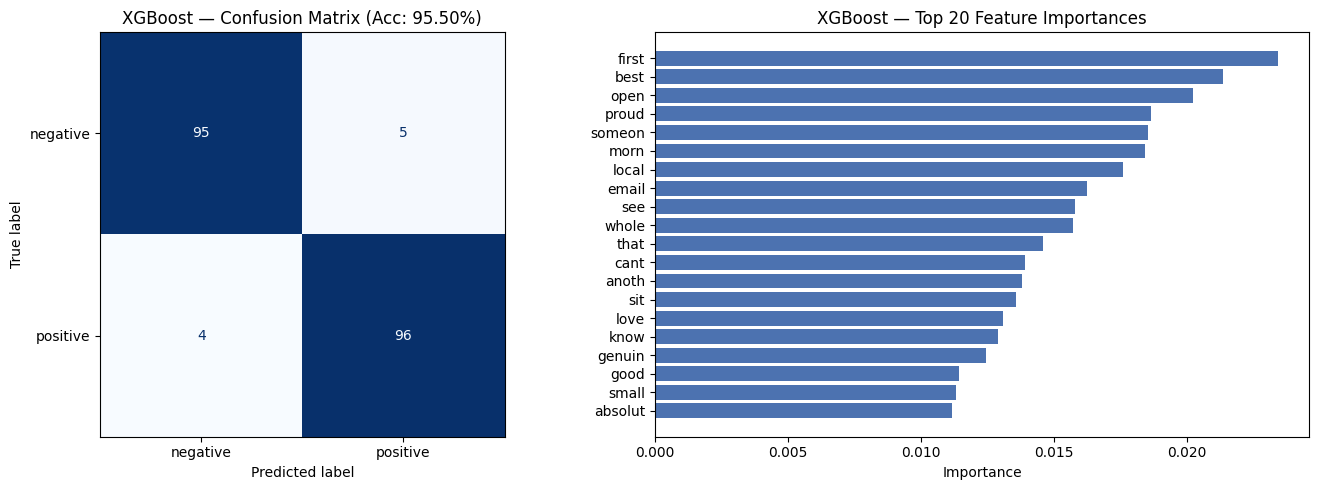

In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    eval_metric='logloss', random_state=42, verbosity=0)
xgb_model.fit(X_train_bow, y_train)
y_pred_xgb = xgb_model.predict(X_test_bow)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.4f}\n")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=le.classes_).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'XGBoost — Confusion Matrix (Acc: {xgb_acc:.2%})')

feat_names = bow_vec.get_feature_names_out()
top_idx = np.argsort(xgb_model.feature_importances_)[-20:][::-1]
axes[1].barh(feat_names[top_idx][::-1], xgb_model.feature_importances_[top_idx][::-1], color='#4C72B0')
axes[1].set_title('XGBoost — Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('xgb_results.png', dpi=150, bbox_inches='tight')
plt.show()


### XGBoost — Live Prediction Widget

In [14]:
def predict_xgb(text):
    vec = bow_vec.transform([clean_text(text)]).toarray()
    pred = xgb_model.predict(vec)[0]
    proba = xgb_model.predict_proba(vec)[0]
    label = le.inverse_transform([pred])[0]
    print(f"\nInput      : {text}")
    print(f"Prediction : {label}")
    print(f"Confidence : Negative={proba[0]:.2%}  |  Positive={proba[1]:.2%}")

txt_xgb = widgets.Textarea(value='I hate the day today.',
    description='Tweet:', layout=widgets.Layout(width='60%', height='70px'))
btn_xgb = widgets.Button(description='Predict (XGBoost)', button_style='info')
out_xgb = widgets.Output()

def _xgb(b):
    with out_xgb:
        out_xgb.clear_output()
        predict_xgb(txt_xgb.value)

btn_xgb.on_click(_xgb)
print(display(widgets.VBox([txt_xgb, btn_xgb, out_xgb])))


None


## 7. Word Embeddings

Word embeddings place words in a continuous vector space where **semantic similarity = geometric proximity**.

The famous analogy:  **king − man + woman ≈ queen**

demonstrates that relationships are encoded as *directions* in this space.

We will:
1. Train Word2Vec on our corpus
2. Load pretrained **GloVe-Twitter-25** (trained on 2B tweets — ideal for our data)
3. Demonstrate analogies
4. Visualise the embedding space


In [29]:
# Train Word2Vec on our corpus
corpus_sentences = [text.split() for text in df['clean_raw']]
w2v = Word2Vec(sentences=corpus_sentences, vector_size=100,
               window=5, min_count=1, workers=4, epochs=50, seed=42)
print(f"Corpus W2V vocab size: {len(w2v.wv)}")

print("\nMost similar to 'something' (corpus):")
try:    print(w2v.wv.most_similar('something', topn=5))
except: print("  not in vocab")

print("\nMost similar to 'happen' (corpus):")
try:    print(w2v.wv.most_similar('happen', topn=5))
except: print("  not in vocab")


Corpus W2V vocab size: 1106

Most similar to 'something' (corpus):
[('ready', 0.7546666860580444), ('builds', 0.7444998025894165), ('mountains', 0.7384928464889526), ('open', 0.735052764415741), ('entirely', 0.7294538617134094)]

Most similar to 'happen' (corpus):
[('dish', 0.8786110877990723), ('things', 0.8439680337905884), ('ever', 0.7969399690628052), ('eaten', 0.7776241302490234), ('city', 0.772749662399292)]


In [30]:
# Load pretrained GloVe-Twitter-25 for proper analogies
# First run downloads ~105 MB — subsequent runs use cache
print("Loading GloVe-Twitter-25 pretrained model (Twitter-trained, 25 dims)...")
glove = gensim_api.load('glove-twitter-25')
print(f"GloVe vocab: {len(glove):,} words")

print("\n--- king - man + woman ---")
for w, s in glove.most_similar(positive=['king','woman'], negative=['man'], topn=5):
    print(f"  {w:<15s} {s:.4f}")

print("\n--- paris - france + italy (capital analogy) ---")
for w, s in glove.most_similar(positive=['paris','italy'], negative=['france'], topn=5):
    print(f"  {w:<15s} {s:.4f}")

print("\n--- good - best + worst (antonym direction) ---")
for w, s in glove.most_similar(positive=['good','worst'], negative=['best'], topn=5):
    print(f"  {w:<15s} {s:.4f}")

print("\n--- Words similar to 'nairobi' ---")
try:
    for w, s in glove.most_similar('nairobi', topn=5):
        print(f"  {w:<15s} {s:.4f}")
except:
    print("  not in vocab")


Loading GloVe-Twitter-25 pretrained model (Twitter-trained, 25 dims)...
[==================================================] 100.0% 104.8/104.8MB downloaded
GloVe vocab: 1,193,514 words

--- king - man + woman ---
  meets           0.8842
  prince          0.8322
  queen           0.8257
  ’s              0.8174
  crow            0.8135

--- paris - france + italy (capital analogy) ---
  brazil          0.8409
  thailand        0.7927
  milan           0.7709
  roma            0.7669
  regina          0.7601

--- good - best + worst (antonym direction) ---
  worse           0.9362
  sick            0.8997
  sudden          0.8973
  happens         0.8879
  period          0.8795

--- Words similar to 'nairobi' ---
  abuja           0.9443
  dearborn        0.9435
  hartford        0.9419
  suffolk         0.9385
  northwest       0.9332


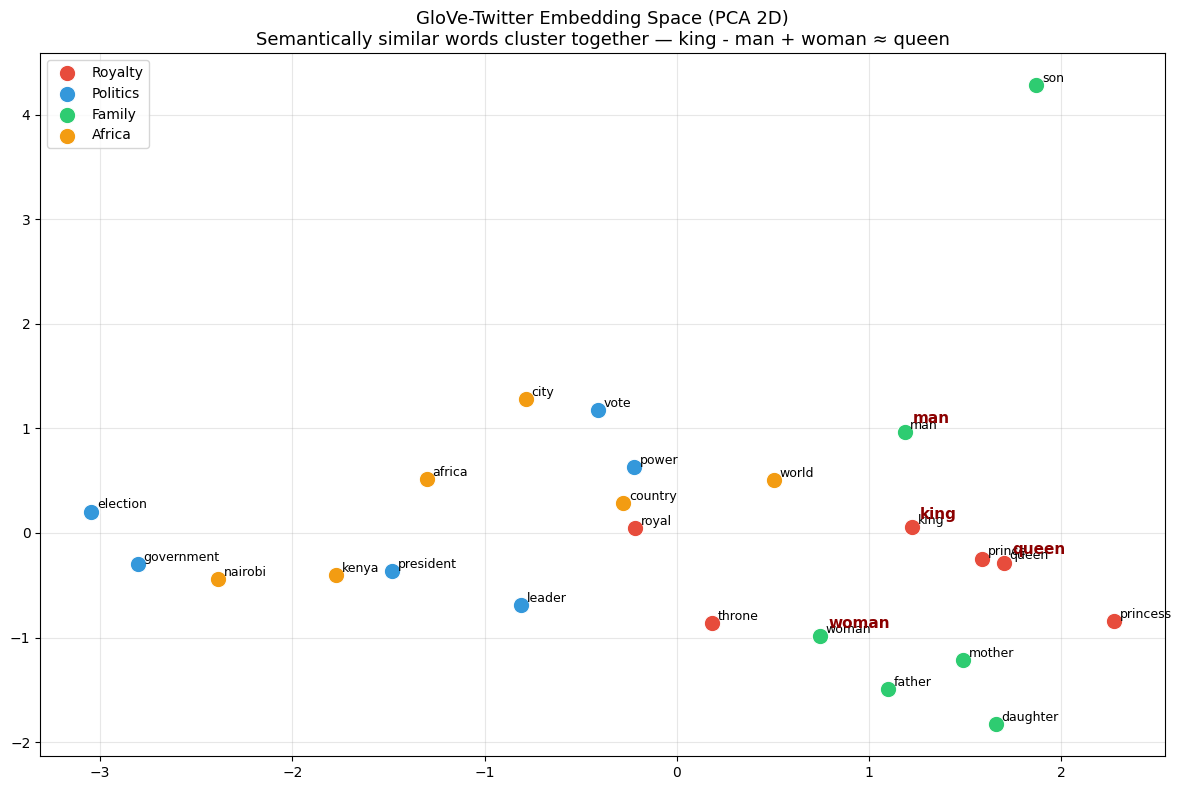

In [31]:
# Visualise embedding space — PCA
WORD_GROUPS = {
    'Royalty'  : ['king', 'queen', 'prince', 'princess', 'throne', 'royal'],
    'Politics' : ['president', 'government', 'election', 'vote', 'leader', 'power'],
    'Family'   : ['man', 'woman', 'father', 'mother', 'son', 'daughter'],
    'Africa'   : ['africa', 'kenya', 'nairobi', 'country', 'city', 'world'],
}
GROUP_COLORS = {'Royalty':'#e74c3c','Politics':'#3498db','Family':'#2ecc71','Africa':'#f39c12'}

valid_words, valid_groups = [], []
for group, words in WORD_GROUPS.items():
    for w in words:
        if w in glove:
            valid_words.append(w)
            valid_groups.append(group)

vecs = np.array([glove[w] for w in valid_words])
coords = PCA(n_components=2, random_state=42).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(12, 8))
for group in WORD_GROUPS:
    idx = [i for i, g in enumerate(valid_groups) if g == group]
    ax.scatter(coords[idx,0], coords[idx,1], c=GROUP_COLORS[group],
               s=140, label=group, zorder=3, edgecolors='white', linewidths=0.8)
    for i in idx:
        ax.annotate(valid_words[i], (coords[i,0]+0.03, coords[i,1]+0.03), fontsize=9)

# Highlight the analogy words
for w in ['king','man','woman','queen']:
    if w in valid_words:
        i = valid_words.index(w)
        ax.annotate(w, coords[i], fontsize=11, fontweight='bold',
                    color='darkred', xytext=(6,6), textcoords='offset points')

ax.set_title("GloVe-Twitter Embedding Space (PCA 2D)\n"
             "Semantically similar words cluster together — king - man + woman ≈ queen",
             fontsize=13)
ax.legend(loc='best'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embedding_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()


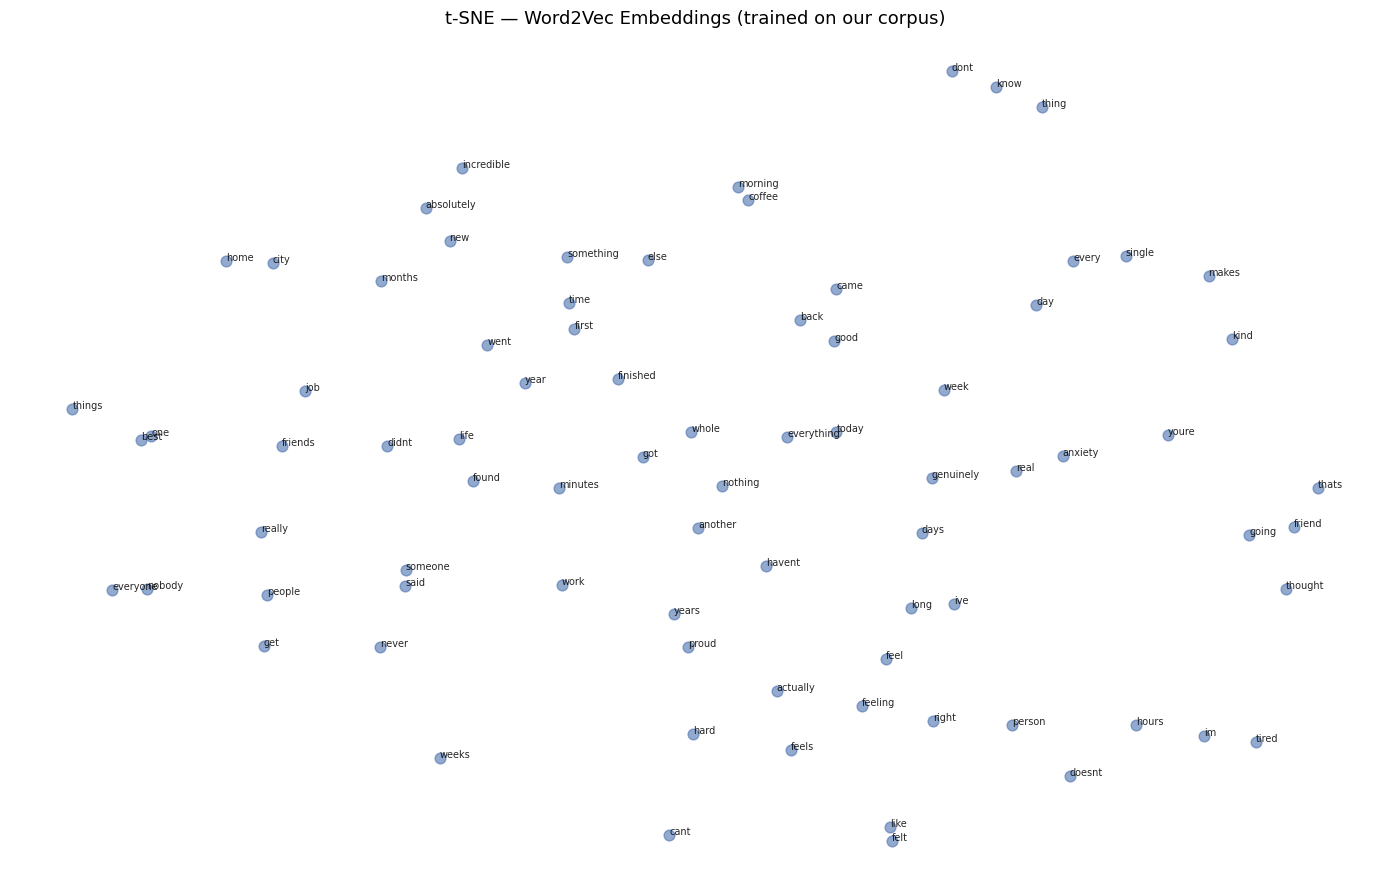

In [32]:
# t-SNE on corpus vocabulary
vocab_w = list(w2v.wv.key_to_index.keys())[:80]
vecs_c  = np.array([w2v.wv[w] for w in vocab_w])
tsne_coords = TSNE(n_components=2, random_state=42,
                   perplexity=min(20, len(vocab_w)-1)).fit_transform(vecs_c)

fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(tsne_coords[:,0], tsne_coords[:,1], alpha=0.6, s=60, c='#4C72B0')
for i, w in enumerate(vocab_w):
    ax.annotate(w, tsne_coords[i], fontsize=7, alpha=0.85)
ax.set_title("t-SNE — Word2Vec Embeddings (trained on our corpus)", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_corpus.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model 2 — embeddings on Gradient boosting


In [55]:

from xgboost import XGBClassifier


# ── 1. Tokenise for Word2Vec (use clean_raw — unstemmed preserves semantics) ──
df['tokens'] = df['clean_raw'].apply(str.split)

# ── 2. Train Word2Vec ─────────────────────────────────────────────────────────
w2v = Word2Vec(
    sentences   = df['tokens'],
    vector_size = 100,        # embedding dimensions
    window      = 5,          # context window
    min_count   = 1,          # include rare words (small corpus)
    workers     = 4,
    epochs      = 20,
    seed        = 42
)

print(f"Vocabulary size : {len(w2v.wv)}")
print(f"Available words : {w2v.wv.index_to_key[:20]}")   # top 20 by freq

# ── 3. Document → embedding (mean-pool word vectors) ─────────────────────────
def doc_vector(tokens, model, size=100):
    """Average the word vectors for all known tokens in a document."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X = np.vstack(df['tokens'].apply(lambda t: doc_vector(t, w2v)))
print(f"\nEmbedding matrix shape: {X.shape}")   # (n_docs, 100)

# ── 4. Encode labels ──────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['language'])            # 'positive' / 'negative' / …
print(f"Classes         : {le.classes_}")

# ── 5. Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 6. XGBoost classifier ─────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_lambda        = 1.0,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    early_stopping_rounds = 20,
    random_state      = 42,
    n_jobs            = -1
)

xgb.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = 50            # print every 50 rounds
)

# ── 7. Evaluate ───────────────────────────────────────────────────────────────
y_pred = xgb.predict(X_test)

print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── 8. Optional: inspect feature importances (which embedding dims matter) ───
importances = pd.Series(xgb.feature_importances_,
                        index=[f"dim_{i}" for i in range(X.shape[1])])
print("\nTop 10 embedding dimensions by importance:")
print(importances.nlargest(10).to_string())

Vocabulary size : 1106
Available words : ['today', 'im', 'got', 'genuinely', 'day', 'ive', 'everything', 'like', 'every', 'feel', 'people', 'one', 'first', 'years', 'work', 'something', 'months', 'everyone', 'cant', 'right']

Embedding matrix shape: (1000, 100)
Classes         : ['negative' 'positive']
[0]	validation_0-logloss:0.67317
[50]	validation_0-logloss:0.27746
[100]	validation_0-logloss:0.16283
[150]	validation_0-logloss:0.10158
[200]	validation_0-logloss:0.07523
[250]	validation_0-logloss:0.06337
[299]	validation_0-logloss:0.05657

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.96      1.00      0.98       100
    positive       1.00      0.96      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200


Top 10 embedding dimensions by importance:
dim_16    0.050405
dim_85 

## 10. Model 4 — H2O AutoML

H2O AutoML automatically trains and stacks multiple algorithms:
GBM, XGBoost, Deep Learning, GLM, Random Forest, Stacked Ensembles —
then returns a ranked **leaderboard**.

> Requires Java. Install H2O: `pip install h2o`


In [44]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(max_mem_size='2G', nthreads=-1)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\johnkk\.virtualenvs\AI-ML-Workshop-2026-Swn2x-P5\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\johnkk\AppData\Local\Temp\tmpcmph0jpz
  JVM stdout: C:\Users\johnkk\AppData\Local\Temp\tmpcmph0jpz\h2o_johnkk_started_from_python.out
  JVM stderr: C:\Users\johnkk\AppData\Local\Temp\tmpcmph0jpz\h2o_johnkk_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Europe/Berlin
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 6 days
H2O_cluster_name:,H2O_from_python_johnkk_i5zvkv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.982 Gb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


In [45]:
# TF-IDF features for H2O tabular input
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['cleaned']).toarray()
feat_cols = [f'f{i}' for i in range(X_tfidf.shape[1])]

df_h2o = pd.DataFrame(X_tfidf, columns=feat_cols)
df_h2o['label'] = df['language'].values

hf = h2o.H2OFrame(df_h2o)
hf['label'] = hf['label'].asfactor()

train_hf, test_hf = hf.split_frame(ratios=[0.8], seed=42)
print(f"H2O train: {train_hf.shape}  |  test: {test_hf.shape}")


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2O train: (788, 501)  |  test: (212, 501)


In [48]:
aml = H2OAutoML(max_runtime_secs=180, max_models=15, seed=42,
                sort_metric='mean_per_class_error', nfolds=5)
aml.train(x=feat_cols, y='label', training_frame=train_hf)

print("\nAutoML Leaderboard (top 10):")
aml.leaderboard.head(10)


AutoML progress: |
15:48:51.927: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%

AutoML Leaderboard (top 10):


model_id,mean_per_class_error,auc,logloss,aucpr,rmse,mse
GBM_5_AutoML_2_20260418_154851,0.00128205,0.999981,0.0244419,0.99998,0.0742557,0.00551391
GBM_4_AutoML_2_20260418_154851,0.00379461,0.998689,0.0383306,0.99839,0.0870459,0.00757699
GLM_1_AutoML_2_20260418_154851,0.00512821,0.999723,0.0286571,0.999725,0.0917686,0.00842148
GBM_3_AutoML_2_20260418_154851,0.00756346,0.998264,0.0538365,0.998039,0.106775,0.0114009
GBM_2_AutoML_2_20260418_154851,0.00756346,0.997922,0.0550791,0.998046,0.105937,0.0112226
DeepLearning_1_AutoML_2_20260418_154851,0.0366899,0.983211,0.154487,0.979011,0.198311,0.0393271
XRT_1_AutoML_2_20260418_154851,0.0521002,0.98466,0.40154,0.985303,0.3415,0.116622
DRF_1_AutoML_2_20260418_154851,0.0597926,0.979597,0.402227,0.981279,0.341991,0.116958
GBM_1_AutoML_2_20260418_154851,0.5,0.54654,0.683336,0.556626,0.495138,0.245162


Best model : GBM_5_AutoML_2_20260418_154851
Accuracy   : 1.0000


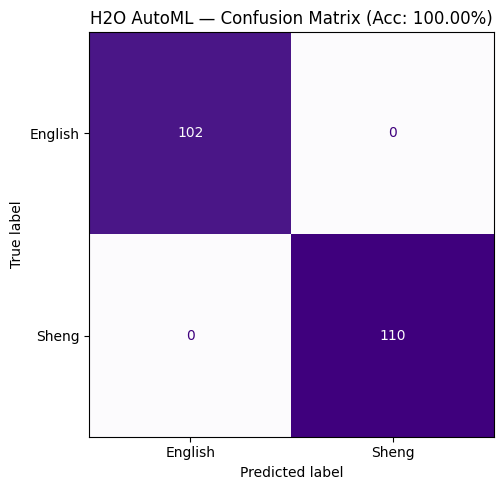

In [51]:
best_h2o = aml.leader
perf_h2o = best_h2o.model_performance(test_hf)
h2o_acc  = perf_h2o.accuracy()[0][1]          # clean scalar, no dict gymnastics

print(f"Best model : {best_h2o.model_id}")
print(f"Accuracy   : {h2o_acc:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_list = perf_h2o.confusion_matrix().to_list()

# to_list() returns rows with a trailing 'Error' column — slice to [0:2] only
cm_h2o = np.array([[cm_list[0][0], cm_list[0][1]],
                   [cm_list[1][0], cm_list[1][1]]])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_h2o, display_labels=['English', 'Sheng']).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'H2O AutoML — Confusion Matrix (Acc: {h2o_acc:.2%})')
plt.tight_layout()
plt.savefig('h2o_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### H2O AutoML — Live Prediction Widget

In [ ]:
def predict_h2o(text):
    cleaned = clean_text(text)
    vec     = tfidf.transform([cleaned]).toarray()
    row_hf  = h2o.H2OFrame(pd.DataFrame(vec, columns=feat_cols))
    pred_df = best_h2o.predict(row_hf).as_data_frame()
    label   = pred_df['predict'].iloc[0]
    p_eng   = pred_df.get('English', pd.Series([None])).iloc[0]
    p_shn   = pred_df.get('Sheng',   pd.Series([None])).iloc[0]
    print(f"\nInput      : {text}")
    print(f"Prediction : {label}")
    if p_eng is not None:
        print(f"Confidence : English={float(p_eng):.2%}  |  Sheng={float(p_shn):.2%}")

txt_h2o = widgets.Textarea(value='I bought a new phone yesterday and it didnt work, these guys are scammers',
    description='Tweet:', layout=widgets.Layout(width='60%', height='70px'))
btn_h2o = widgets.Button(description='Predict (H2O AutoML)', button_style='danger')
out_h2o = widgets.Output()

def _h2o(b):
    with out_h2o:
        out_h2o.clear_output()
        predict_h2o(txt_h2o.value)

btn_h2o.on_click(_h2o)
display(widgets.VBox([txt_h2o, btn_h2o, out_h2o]))


## 11. Model Comparison

                        Accuracy  F1 (macro)
XGBoost\n(BoW)             0.955      0.9550
SpaCy+LR\n(pretrained)     0.860      0.8599
H2O\nAutoML                1.000      1.0000


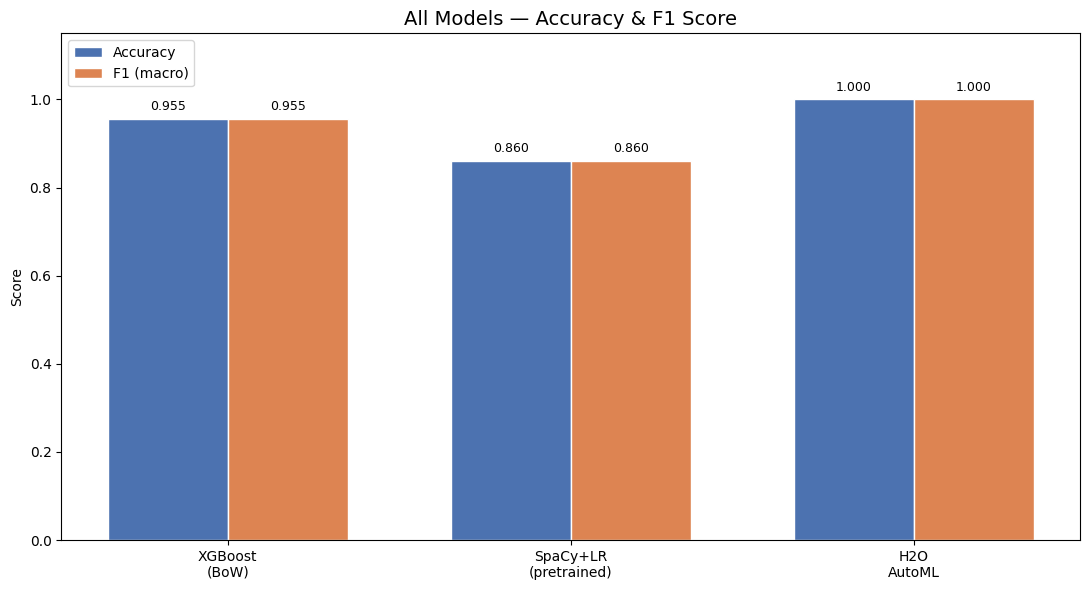

In [56]:
results = {
    'XGBoost\n(BoW)':          {'Accuracy': xgb_acc,
                                 'F1 (macro)': f1_score(y_test, y_pred_xgb, average='macro')},
    'SpaCy+LR\n(pretrained)':  {'Accuracy': spacy_acc,
                                 'F1 (macro)': f1_score(y_test, y_pred_sp, average='macro')},
    # 'LSTM\n(Deep Learning)':   {'Accuracy': dl_acc,
    #                              'F1 (macro)': f1_score(y_te_dl, y_pred_dl, average='macro')},
    'H2O\nAutoML':             {'Accuracy': h2o_acc, 'F1 (macro)': h2o_acc},
}
results_df = pd.DataFrame(results).T
print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(results_df)); w = 0.35
b1 = ax.bar(x - w/2, results_df['Accuracy'],   w, label='Accuracy',   color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, results_df['F1 (macro)'], w, label='F1 (macro)', color='#DD8452', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.legend()
ax.set_title('All Models — Accuracy & F1 Score', fontsize=14)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

| Model | Features | Highlights |
|---|---|---|
| **XGBoost** | BoW unigrams+bigrams | Fast, interpretable, feature importance |
| **SpaCy** | 300d pretrained GloVe | Semantic transfer learning |
| **LSTM** | Learned embeddings | Sequential context, end-to-end |
| **H2O AutoML** | TF-IDF | Automated model search + ensembling |

**Key takeaways:**
- Sheng-specific stopwords improve signal quality
- Pretrained embeddings (SpaCy / GloVe) beat BoW on semantic tasks
- Word analogies (*king − man + woman = queen*) reveal geometry of meaning
- H2O AutoML removes manual hyperparameter tuning overhead
